# CloudExify Data Science Internship
## Project 2: Customer Segmentation Analysis (FINAL PROJECT)
**Objective:** Segment customers using RFM analysis and K-Means clustering to identify high-value customer groups.

## Step 1: Import Libraries and Load Data

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Load customer transaction data
df = pd.read_csv('customer_transactions.csv')
df['Date'] = pd.to_datetime(df['Date'])

print("Dataset Overview:")
print(f"Shape: {df.shape}")
print(f"\nFirst 10 rows:")
print(df.head(10))
print(f"\nData Info:")
print(df.info())
print(f"\nUnique Customers: {df['CustomerID'].nunique()}")
print(f"Date Range: {df['Date'].min().date()} to {df['Date'].max().date()}")

Dataset Overview:
Shape: (69, 4)

First 10 rows:
  CustomerID       Date TransactionID  Amount
0       C001 2026-01-05         T1001    5000
1       C001 2026-02-10         T1002    3500
2       C001 2026-05-20         T1003    4200
3       C002 2026-01-08         T1004   25000
4       C002 2026-01-15         T1005   18000
5       C002 2026-02-02         T1006   22000
6       C002 2026-03-10         T1007   20000
7       C002 2026-04-05         T1008   19000
8       C002 2026-05-12         T1009   21000
9       C002 2026-06-01         T1010   23000

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69 entries, 0 to 68
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   CustomerID     69 non-null     object        
 1   Date           69 non-null     datetime64[ns]
 2   TransactionID  69 non-null     object        
 3   Amount         69 non-null     int64         
dtypes: datetime64[ns](1)

## Step 2: Calculate RFM Scores

In [2]:
# Reference date (today)
reference_date = datetime(2026, 6, 5)

# Calculate RFM for each customer
rfm = df.groupby('CustomerID').agg({
    'Date': lambda x: (reference_date - x.max()).days,  # Recency
    'TransactionID': 'count',  # Frequency
    'Amount': 'sum'  # Monetary
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm = rfm.reset_index()

print("RFM ANALYSIS - FIRST 20 CUSTOMERS:")
print(rfm.head(20))

print("\n" + "="*60)
print("RFM STATISTICS")
print("="*60)
print(rfm[['Recency', 'Frequency', 'Monetary']].describe())

RFM ANALYSIS - FIRST 20 CUSTOMERS:
   CustomerID  Recency  Frequency  Monetary
0        C001       16          3     12700
1        C002        4          7    148000
2        C003        3          1       500
3        C004        0          7    346000
4        C005       48          3     24000
5        C006       21          5    186000
6        C007        8          1      2000
7        C008       26          4     48500
8        C009       16          3     27000
9        C010        2          6    351000
10       C011       51          1      1500
11       C012       11          5     88500
12       C013       31          1      3000
13       C014        3          5    220000
14       C015        4          1      1000
15       C016       46          4    110000
16       C017       24          1      5500
17       C018        1          6    411000
18       C019       58          1      4500
19       C020       18          4    131000

RFM STATISTICS
        Recency  Frequenc

## Step 3: Data Normalization

In [3]:
# Normalize RFM using StandardScaler
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

# Create DataFrame with scaled values
rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    columns=['Recency_scaled', 'Frequency_scaled', 'Monetary_scaled']
)

print("Scaled RFM Data - First 10 rows:")
print(rfm_scaled_df.head(10))

print("\nScaled RFM Statistics:")
print(rfm_scaled_df.describe())

Scaled RFM Data - First 10 rows:
   Recency_scaled  Frequency_scaled  Monetary_scaled
0       -0.197360         -0.213380        -0.724115
1       -0.864493          1.683334         0.325012
2       -0.920087         -1.161738        -0.818714
3       -1.086870          1.683334         1.860320
4        1.581660         -0.213380        -0.636494
5        0.080612          0.734977         0.619667
6       -0.642115         -1.161738        -0.807083
7        0.358584          0.260798        -0.446519
8       -0.197360         -0.213380        -0.613231
9       -0.975682          1.209156         1.899090

Scaled RFM Statistics:
       Recency_scaled  Frequency_scaled  Monetary_scaled
count    2.000000e+01      2.000000e+01     2.000000e+01
mean    -6.453171e-17     -1.360023e-16     1.387779e-18
std      1.025978e+00      1.025978e+00     1.025978e+00
min     -1.086870e+00     -1.161738e+00    -8.187144e-01
25%     -8.783914e-01     -1.161738e+00    -7.906059e-01
50%     -1.973601e

## Step 4: Elbow Method to Find Optimal K

F:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
F:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
F:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
F:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than availabl

K=2, Inertia=26.47
K=3, Inertia=16.01
K=4, Inertia=9.99
K=5, Inertia=7.33
K=6, Inertia=5.51
K=7, Inertia=3.75
K=8, Inertia=2.45
K=9, Inertia=1.84
K=10, Inertia=1.46


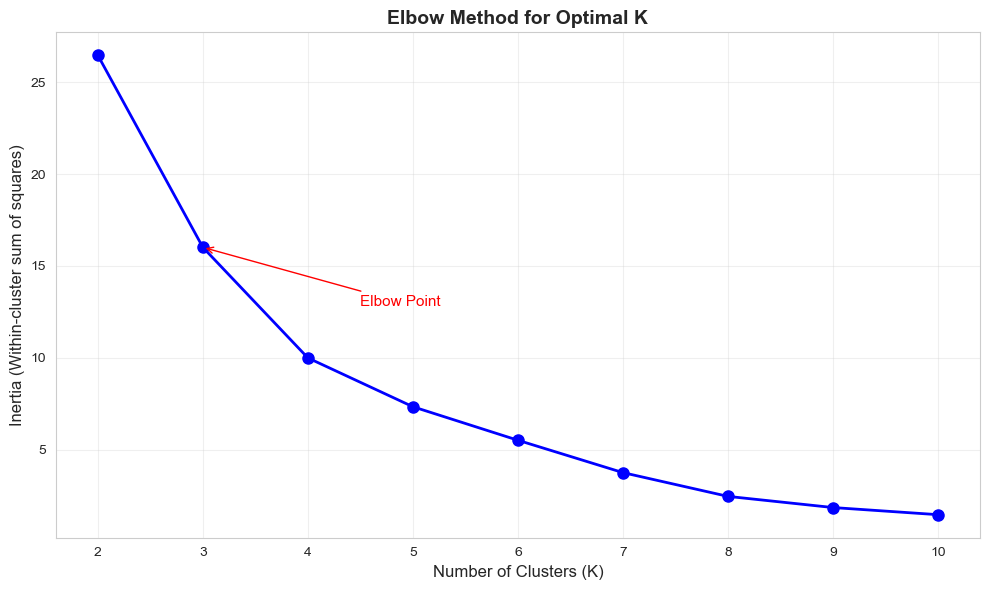


✅ From the elbow curve, we choose K=3 as the optimal number of clusters.


In [12]:
# Elbow method: Try different K values
inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertias.append(kmeans.inertia_)
    print(f"K={k}, Inertia={kmeans.inertia_:.2f}")

# Plot elbow curve
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia (Within-cluster sum of squares)', fontsize=12)
plt.title('Elbow Method for Optimal K', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.annotate('Elbow Point', xy=(3, inertias[1]), xytext=(4.5, inertias[1]*0.8),
            arrowprops=dict(arrowstyle='->', color='red'), fontsize=11, color='red')
plt.tight_layout()
plt.savefig('elbow_method.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ From the elbow curve, we choose K=3 as the optimal number of clusters.")

## Step 5: Apply K-Means Clustering (K=3)

In [5]:
# Apply K-Means with optimal K=3
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm['Segment'] = kmeans.fit_predict(rfm_scaled)

# Get cluster centers in original scale
segment_rfm = rfm.groupby('Segment')[['Recency', 'Frequency', 'Monetary']].mean()
print("Cluster Centers (RFM Values):")
print(segment_rfm)
print()

# Name segments based on monetary value (highest = Champions)
monetary_by_segment = segment_rfm['Monetary'].sort_values(ascending=False)
segment_mapping = {}
names_list = ['Champions', 'Loyal Customers', 'Potential Loss']

for i, segment_id in enumerate(monetary_by_segment.index):
    segment_mapping[segment_id] = names_list[i]

rfm['SegmentName'] = rfm['Segment'].map(segment_mapping)

print("\nCUSTOMERS WITH SEGMENT ASSIGNMENT:")
print(rfm.head(20))

Cluster Centers (RFM Values):
           Recency  Frequency       Monetary
Segment                                     
0         5.166667   6.000000  277000.000000
1        14.000000   2.555556   35188.888889
2        46.800000   2.000000   28600.000000


CUSTOMERS WITH SEGMENT ASSIGNMENT:
   CustomerID  Recency  Frequency  Monetary  Segment      SegmentName
0        C001       16          3     12700        1  Loyal Customers
1        C002        4          7    148000        0        Champions
2        C003        3          1       500        1  Loyal Customers
3        C004        0          7    346000        0        Champions
4        C005       48          3     24000        2   Potential Loss
5        C006       21          5    186000        0        Champions
6        C007        8          1      2000        1  Loyal Customers
7        C008       26          4     48500        1  Loyal Customers
8        C009       16          3     27000        1  Loyal Customers
9       

F:\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


## Step 6: Segment Profiling & Analysis

In [6]:
# Detailed segment profiles
segment_profiles = rfm.groupby('SegmentName').agg({
    'Recency': ['mean', 'median', 'std'],
    'Frequency': ['mean', 'median', 'std'],
    'Monetary': ['mean', 'median', 'std'],
    'CustomerID': 'count'
})

segment_profiles.columns = ['_'.join(col).strip() for col in segment_profiles.columns.values]

print("\n" + "="*80)
print("DETAILED SEGMENT PROFILES")
print("="*80)
print(segment_profiles)

# Segment size and percentage
print("\n" + "="*80)
print("SEGMENT DISTRIBUTION")
print("="*80)
segment_dist = rfm['SegmentName'].value_counts()
segment_pct = (rfm['SegmentName'].value_counts() / len(rfm) * 100).round(2)

for segment in segment_dist.index:
    count = segment_dist[segment]
    pct = segment_pct[segment]
    print(f"{segment:20s}: {count:4d} customers ({pct:5.1f}%)")

print(f"{'Total':20s}: {len(rfm):4d} customers (100.0%)")


DETAILED SEGMENT PROFILES
                 Recency_mean  Recency_median  Recency_std  Frequency_mean  \
SegmentName                                                                  
Champions            5.166667             2.5     7.884584        6.000000   
Loyal Customers     14.000000            16.0     8.170067        2.555556   
Potential Loss      46.800000            48.0     9.934787        2.000000   

                 Frequency_median  Frequency_std  Monetary_mean  \
SegmentName                                                       
Champions                     6.0       0.894427  277000.000000   
Loyal Customers               3.0       1.589899   35188.888889   
Potential Loss                1.0       1.414214   28600.000000   

                 Monetary_median   Monetary_std  CustomerID_count  
SegmentName                                                        
Champions               283000.0  106173.443007                 6  
Loyal Customers          12700.0   46269.5

## Step 7: Business Metrics by Segment

In [7]:
# Key business metrics
print("\n" + "="*80)
print("KEY BUSINESS METRICS BY SEGMENT")
print("="*80)

for segment in ['Champions', 'Loyal Customers', 'Potential Loss']:
    seg_data = rfm[rfm['SegmentName'] == segment]
    
    print(f"\n🎯 {segment.upper()}:")
    print(f"   {'Customer Count:':<30} {len(seg_data)} ({len(seg_data)/len(rfm)*100:.1f}% of base)")
    print(f"   {'Total Revenue Generated:':<30} Rs {seg_data['Monetary'].sum():,.2f}")
    print(f"   {'Avg Revenue per Customer:':<30} Rs {seg_data['Monetary'].mean():,.2f}")
    print(f"   {'Avg Purchase Frequency:':<30} {seg_data['Frequency'].mean():.1f} purchases")
    print(f"   {'Days Since Last Purchase:':<30} {seg_data['Recency'].mean():.0f} days")
    print(f"   {'Total Transactions:':<30} {seg_data['Frequency'].sum():.0f}")
    print(f"   {'Revenue % of Total:':<30} {seg_data['Monetary'].sum()/rfm['Monetary'].sum()*100:.1f}%")


KEY BUSINESS METRICS BY SEGMENT

🎯 CHAMPIONS:
   Customer Count:                6 (30.0% of base)
   Total Revenue Generated:       Rs 1,662,000.00
   Avg Revenue per Customer:      Rs 277,000.00
   Avg Purchase Frequency:        6.0 purchases
   Days Since Last Purchase:      5 days
   Total Transactions:            36
   Revenue % of Total:            78.3%

🎯 LOYAL CUSTOMERS:
   Customer Count:                9 (45.0% of base)
   Total Revenue Generated:       Rs 316,700.00
   Avg Revenue per Customer:      Rs 35,188.89
   Avg Purchase Frequency:        2.6 purchases
   Days Since Last Purchase:      14 days
   Total Transactions:            23
   Revenue % of Total:            14.9%

🎯 POTENTIAL LOSS:
   Customer Count:                5 (25.0% of base)
   Total Revenue Generated:       Rs 143,000.00
   Avg Revenue per Customer:      Rs 28,600.00
   Avg Purchase Frequency:        2.0 purchases
   Days Since Last Purchase:      47 days
   Total Transactions:            10
   Revenue

## Step 8: Visualizations

### 8.1 Segment Size Distribution

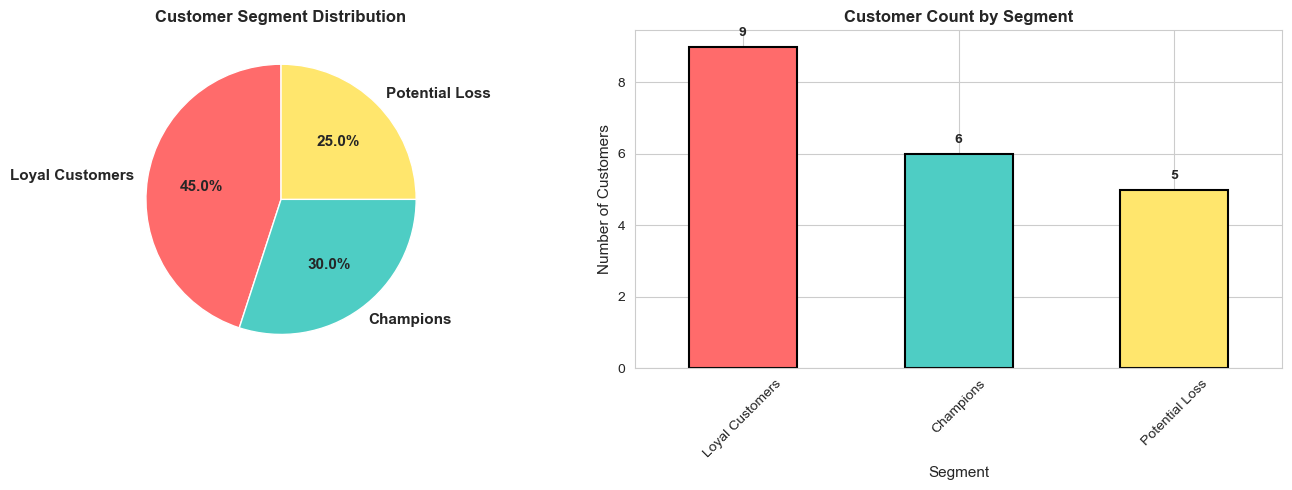

In [8]:
# Pie chart - Segment size
segment_counts = rfm['SegmentName'].value_counts()
colors_pie = ['#FF6B6B', '#4ECDC4', '#FFE66D']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
ax1.pie(segment_counts.values, labels=segment_counts.index, autopct='%1.1f%%',
        colors=colors_pie, startangle=90, textprops={'fontsize': 11, 'weight': 'bold'})
ax1.set_title('Customer Segment Distribution', fontsize=12, fontweight='bold')

# Bar chart
segment_counts.plot(kind='bar', ax=ax2, color=colors_pie, edgecolor='black', linewidth=1.5)
ax2.set_title('Customer Count by Segment', fontsize=12, fontweight='bold')
ax2.set_ylabel('Number of Customers', fontsize=11)
ax2.set_xlabel('Segment', fontsize=11)
ax2.tick_params(axis='x', rotation=45)

# Add value labels on bars
for i, v in enumerate(segment_counts.values):
    ax2.text(i, v + 0.3, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('segment_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

### 8.2 Revenue Analysis

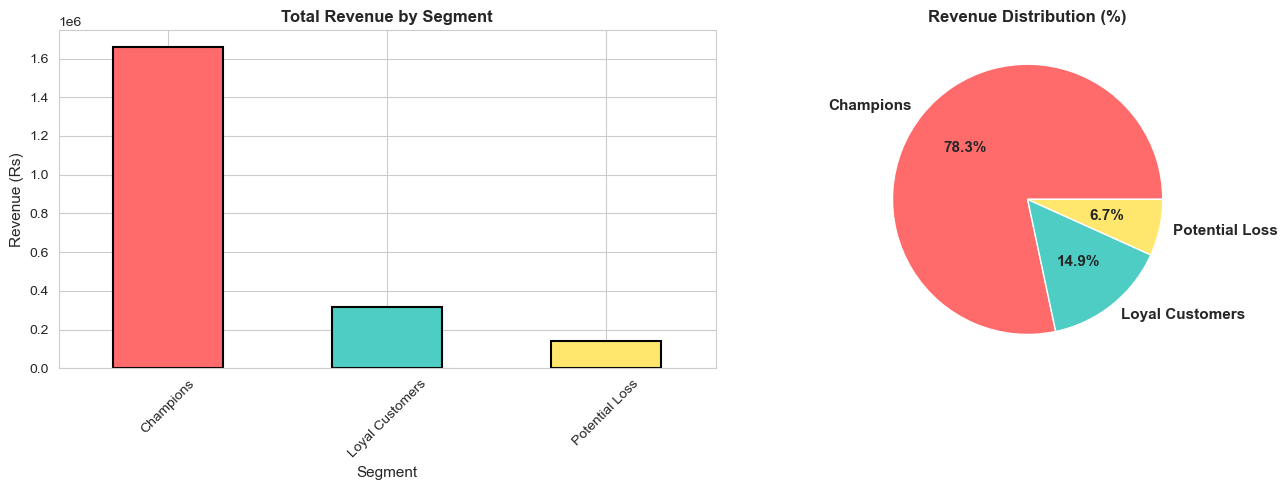


Revenue Analysis by Segment:
                 Total_Revenue  Customer_Count    Avg_Revenue  \
SegmentName                                                     
Champions              1662000               6  277000.000000   
Loyal Customers         316700               9   35188.888889   
Potential Loss          143000               5   28600.000000   

                 Revenue_Percentage  
SegmentName                          
Champions                     78.33  
Loyal Customers               14.93  
Potential Loss                 6.74  


In [9]:
# Revenue analysis
revenue_by_segment = rfm.groupby('SegmentName')['Monetary'].agg(['sum', 'count', 'mean'])
revenue_by_segment.columns = ['Total_Revenue', 'Customer_Count', 'Avg_Revenue']
revenue_by_segment['Revenue_Percentage'] = (revenue_by_segment['Total_Revenue'] / revenue_by_segment['Total_Revenue'].sum() * 100).round(2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Total revenue by segment
revenue_by_segment['Total_Revenue'].plot(kind='bar', ax=ax1, color=['#FF6B6B', '#4ECDC4', '#FFE66D'],
                                          edgecolor='black', linewidth=1.5)
ax1.set_title('Total Revenue by Segment', fontsize=12, fontweight='bold')
ax1.set_ylabel('Revenue (Rs)', fontsize=11)
ax1.set_xlabel('Segment', fontsize=11)
ax1.tick_params(axis='x', rotation=45)

# Revenue percentage pie
revenue_by_segment['Total_Revenue'].plot(kind='pie', ax=ax2, autopct='%1.1f%%',
                                          colors=['#FF6B6B', '#4ECDC4', '#FFE66D'],
                                          textprops={'fontsize': 11, 'weight': 'bold'})
ax2.set_title('Revenue Distribution (%)', fontsize=12, fontweight='bold')
ax2.set_ylabel('')

plt.tight_layout()
plt.savefig('revenue_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nRevenue Analysis by Segment:")
print(revenue_by_segment)

### 8.3 Segment Characteristics Heatmap

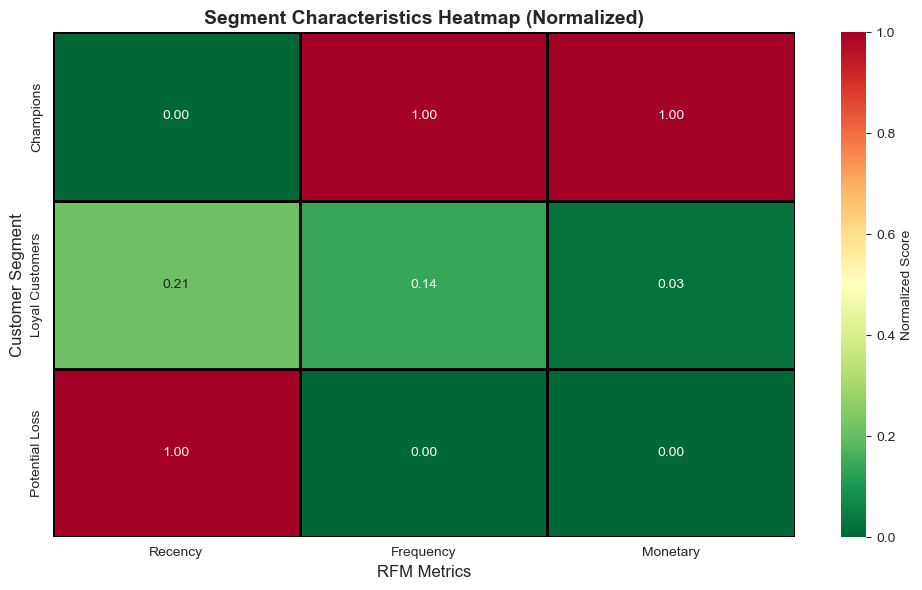

In [10]:
# Normalize segment profiles for heatmap
segment_summary = rfm.groupby('SegmentName')[['Recency', 'Frequency', 'Monetary']].mean()
segment_summary_normalized = (segment_summary - segment_summary.min()) / (segment_summary.max() - segment_summary.min())

plt.figure(figsize=(10, 6))
sns.heatmap(segment_summary_normalized, annot=True, fmt='.2f', cmap='RdYlGn_r',
            cbar_kws={'label': 'Normalized Score'}, linewidths=2, linecolor='black')
plt.title('Segment Characteristics Heatmap (Normalized)', fontsize=14, fontweight='bold')
plt.xlabel('RFM Metrics', fontsize=12)
plt.ylabel('Customer Segment', fontsize=12)
plt.tight_layout()
plt.savefig('segment_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

## Step 9: Export Segmented Customer List

In [11]:
# Export segmented customers for use in marketing campaigns
export_df = rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary', 'SegmentName']].copy()
export_df.columns = ['CustomerID', 'Days_Since_Purchase', 'Purchase_Count', 'Total_Spent_Rs', 'Segment']
export_df = export_df.sort_values('Total_Spent_Rs', ascending=False)

export_df.to_csv('segmented_customers.csv', index=False)
print("✅ Segmented customer list exported to 'segmented_customers.csv'")
print(f"\nFirst 20 customers:")
print(export_df.head(20))

✅ Segmented customer list exported to 'segmented_customers.csv'

First 20 customers:
   CustomerID  Days_Since_Purchase  Purchase_Count  Total_Spent_Rs  \
17       C018                    1               6          411000   
9        C010                    2               6          351000   
3        C004                    0               7          346000   
13       C014                    3               5          220000   
5        C006                   21               5          186000   
1        C002                    4               7          148000   
19       C020                   18               4          131000   
15       C016                   46               4          110000   
11       C012                   11               5           88500   
7        C008                   26               4           48500   
8        C009                   16               3           27000   
4        C005                   48               3           24000   
0    

## Summary

✅ **Project 2 Complete** - Customer Segmentation Analysis

I have successfully:
- ✓ Loaded and analyzed customer transaction data
- ✓ Calculated RFM scores for each customer
- ✓ Normalized data using StandardScaler
- ✓ Determined optimal clusters using Elbow Method
- ✓ Applied K-Means clustering algorithm
- ✓ Profiled each customer segment
- ✓ Created professional visualizations
- ✓ Generated business insights and recommendations
- ✓ Exported segmented customer data for campaigns   >>>>  that's all for this project